In [1]:
import numpy as np

from factors import *

In [2]:
bt = BackTester(fc_name_list=['fac_cumret', 'fac_upperline', 'fac_winrate'],
                instrument_type='futures_continuous_contract',
                instrument_id_list = ['C0', 'FG0'],
                fc_freq = '1d',
                start_time='20230101',
                end_time='20260310',
                portfolio_adjust_method = '1D',
                interest_method = 'compound',
                risk_free_rate=False,
                n_jobs = 5
                )
# bt.backtest()

In [3]:
bt.data

,time,instrument_id,open,high,low,close,volume,position
0,2023-01-03,C0,2829,2842,2817,2840,301325,705314
1,2023-01-04,C0,2840,2877,2838,2875,489218,711148
2,2023-01-05,C0,2875,2882,2859,2878,341944,714472
3,2023-01-06,C0,2873,2892,2867,2886,368002,731213
4,2023-01-09,C0,2882,2895,2879,2890,306730,744645
...,...,...,...,...,...,...,...,...
1531,2026-03-04,FG0,1055,1055,1037,1038,985426,1321021
1532,2026-03-05,FG0,1039,1065,1038,1055,1177512,1263360
1533,2026-03-06,FG0,1056,1093,1052,1087,1384174,1256461
1534,2026-03-09,FG0,1098,1163,1090,1104,3221862,1165149


In [4]:
# self = bt
# Data = self.data
# df = Data.copy()
#
# df = df.sort_values(by='time', ascending=True)
# df = df.set_index(['time', 'instrument_id'])
#
# fc_class_list = [resolve_factor_class(fc_name) for fc_name in self.fc_name_list]
# f = lambda x: get_factor_value_for_one_factor(df, x)
#
# with Parallel(n_jobs=self.n_jobs) as parallel:
#     mapper_list = parallel(delayed(f)(fc_class) for fc_class in fc_class_list)
# mapper_list = [x.reset_index() for x in mapper_list]

In [5]:
bt.fc_name_with_param_list

['fac_cumret_1_50',
 'fac_cumret_1_100',
 'fac_cumret_2_50',
 'fac_cumret_2_100',
 'fac_cumret_3_50',
 'fac_cumret_3_100',
 'fac_upperline_10',
 'fac_upperline_30',
 'fac_winrate_10',
 'fac_winrate_20',
 'fac_winrate_30']

In [6]:
df = bt.data.copy()

In [ ]:
bt.performance_dc['C0']['fac_cumret_1_50']['daily_gross_ret'].copy()

In [ ]:
df[fc_col].ffill().fillna(0)

In [ ]:
bt.ts_performance_summary

In [ ]:
bt.plot_nav()

In [ ]:
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, \
    load_robot_execution_failures
download_robot_execution_failures()
timeseries, y = load_robot_execution_failures()

In [ ]:
print(timeseries.head())

In [ ]:
from tsfresh import extract_features
extracted_features = extract_features(timeseries, column_id="id", column_sort="time")

In [ ]:
timeseries

In [ ]:
extracted_features

In [ ]:
extracted_features.columns

In [ ]:
from factors.factor_auto_search import FactorGenerator

In [ ]:
from factors.factor_auto_search import FactorGenerator

fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0', 'FG0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=200,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)



In [ ]:
generated_df = fg.generate()
fc_subset = fg.generated_fc_name_list
print(len(fg.generated_fc_name_list))
fg.save_fc_value(fc_subset, file_name='tsfresh_fc_subset', file_format='parquet')
bt = fg.backtest(fc_name_list=fc_subset)

In [ ]:
len(fg.generated_fc_name_list)

In [ ]:
bt.plot_nav()

In [ ]:
fg.generated_fc_name_list

In [ ]:
fc_subset = ['close__maximum', 'close__absolute_maximum',
             'position__standard_deviation', 'position__variance']
config_path = fg.save_fc(fc_subset)
selected_fc = FactorGenerator.load_fc(config_path)
print(selected_fc)

In [ ]:
bt2 = fg.backtest_from_fc_config(config_path)

In [ ]:
bt2.performance_summary.loc[bt2.performance_summary['Instrument ID'] == 'C0']

In [ ]:
bt2.plot_nav()

# auto search

## 开始search

In [ ]:
from factors.factor_auto_search import FactorGenerator
fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=20000,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)
# one-step: mine + filter + save high-quality config
result = fg.auto_mine_select_and_save_fc(
    net_ret_threshold=0.05,
    sharpe_threshold=0.8,
    fc_package_name='tsfresh_high_quality_fc_20260317_new',
    require_all_instruments=False
)

In [ ]:
# 全部生成的因子
print("全部生成的因子: ", fg.generated_fc_name_list)
print("选中的因子: ", result['selected_fc_name_list'])
print("计算出的因子值: ", fg.generated_data.head(10))
print("选中因子的回测结果: ", result['bt'].performance_summary)
print("选中因子的净值曲线: ", result['bt'].plot_nav())

## 检查信息泄露

In [ ]:
# 这个代码跑了一个半小时才跑出结果
leakage_check = fg.check_if_leakage(fc_name_list=result['selected_fc_name_list'], raise_error=True)

In [ ]:
leakage_check

In [ ]:
result.keys()

In [ ]:
result['selected_fc_name_list']

In [ ]:
fg.generated_data['close__mean_second_derivative_central']

In [ ]:
df_ps = result['bt'].performance_summary
df_ps.loc[(df_ps['Instrument ID'] == 'C0') & (df_ps['Factor Name'].isin(result['selected_fc_name_list'])]

In [4]:
result['bt'].plot_nav(fc_name=result['selected_fc_name_list'])

NameError: name 'result' is not defined

## llm自动生成因子

In [1]:
from factors.factor_auto_search import FactorGenerator

In [2]:
fg = FactorGenerator(
    method='llm_prompt',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    model_name='deepseek',
    llm_factor_count=5,
    llm_temperature=0.7,
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)

In [4]:
# one-step: mine + filter + save high-quality config
result = fg.auto_mine_select_and_save_fc(
    net_ret_threshold=0.00,
    sharpe_threshold=0.0,
    fc_package_name='tsfresh_high_quality_fc_20260317_from_llm',
    require_all_instruments=False
)


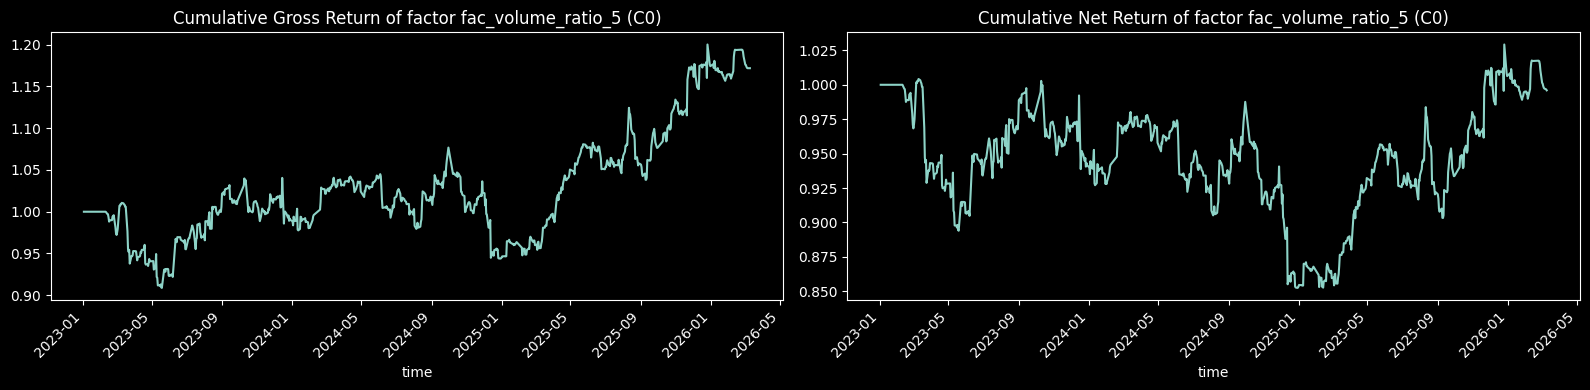

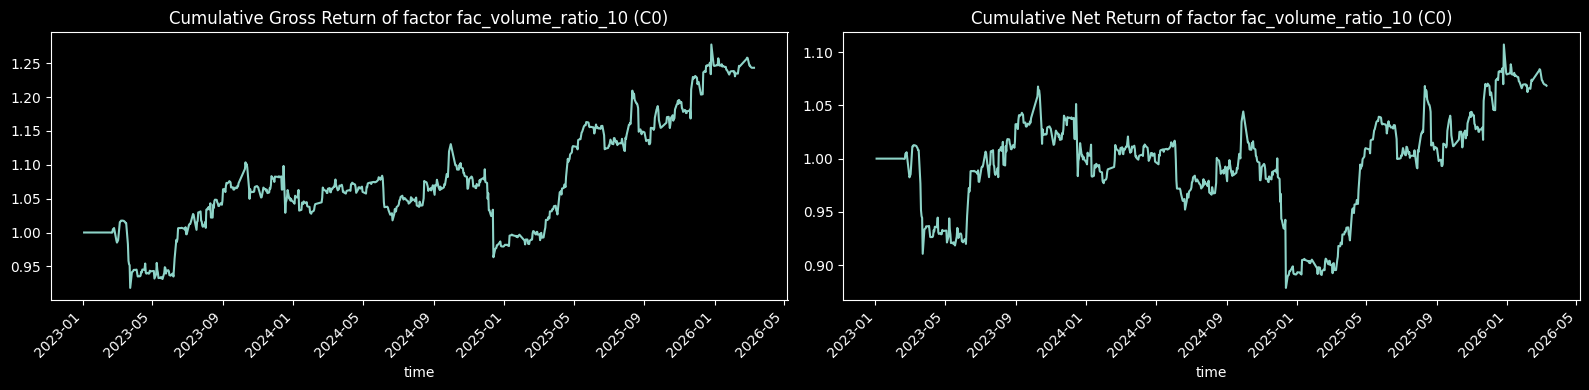

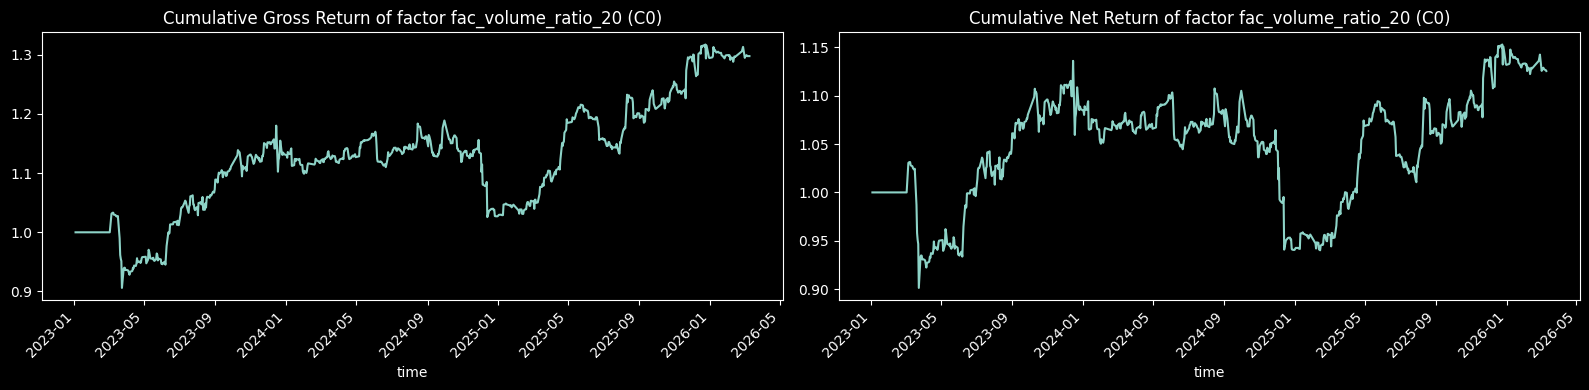

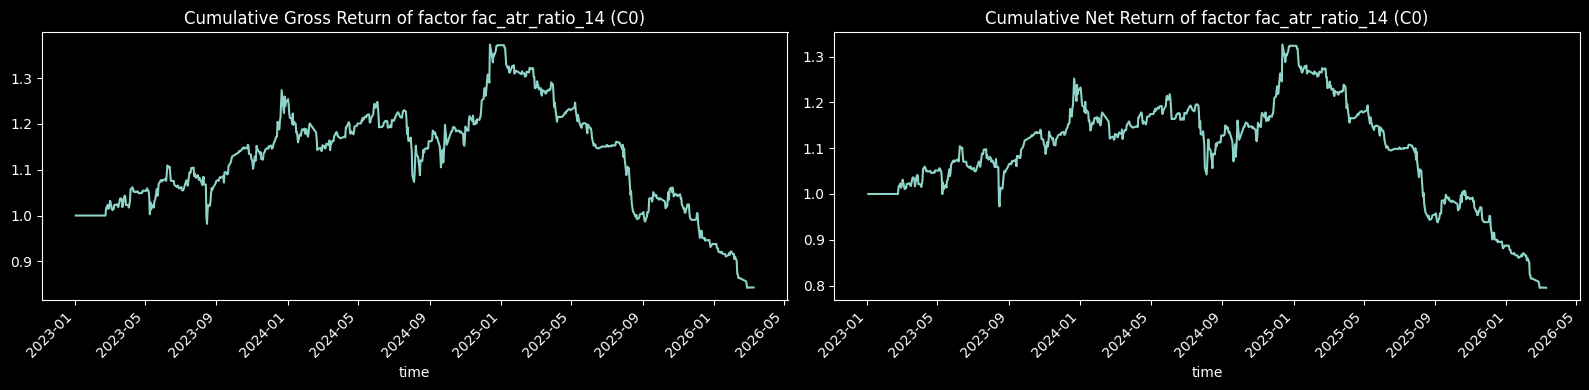

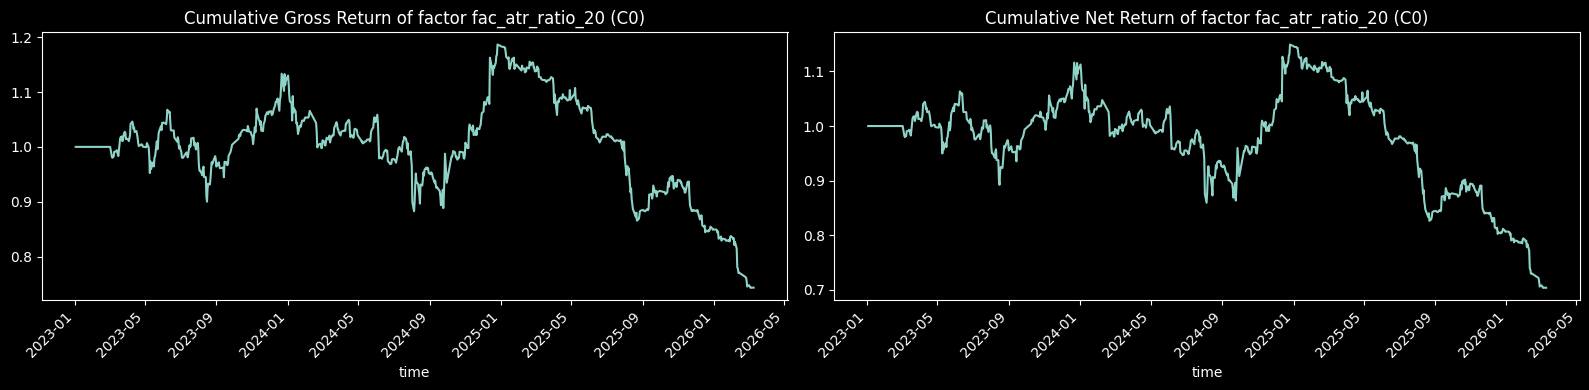

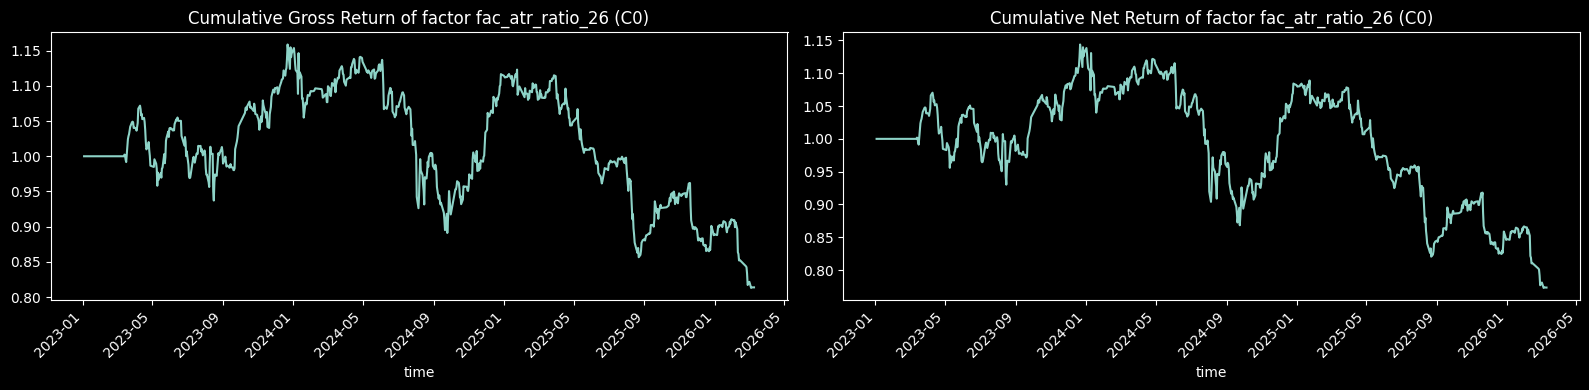

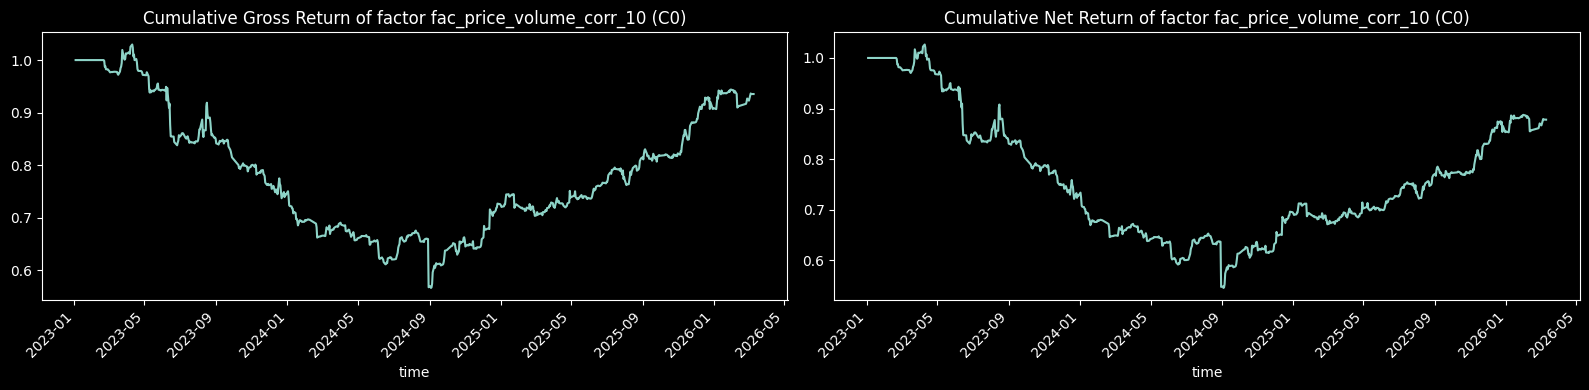

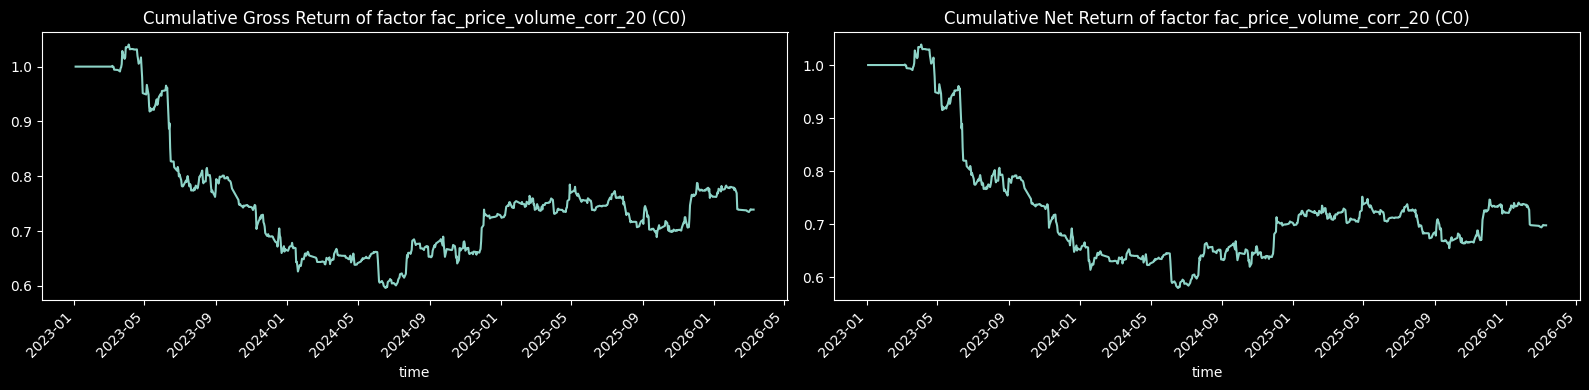

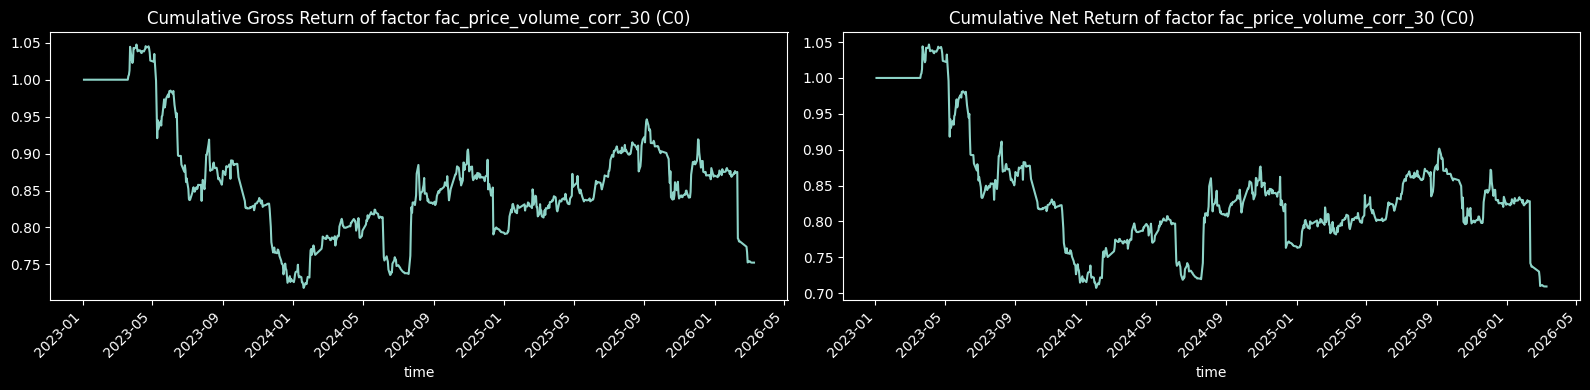

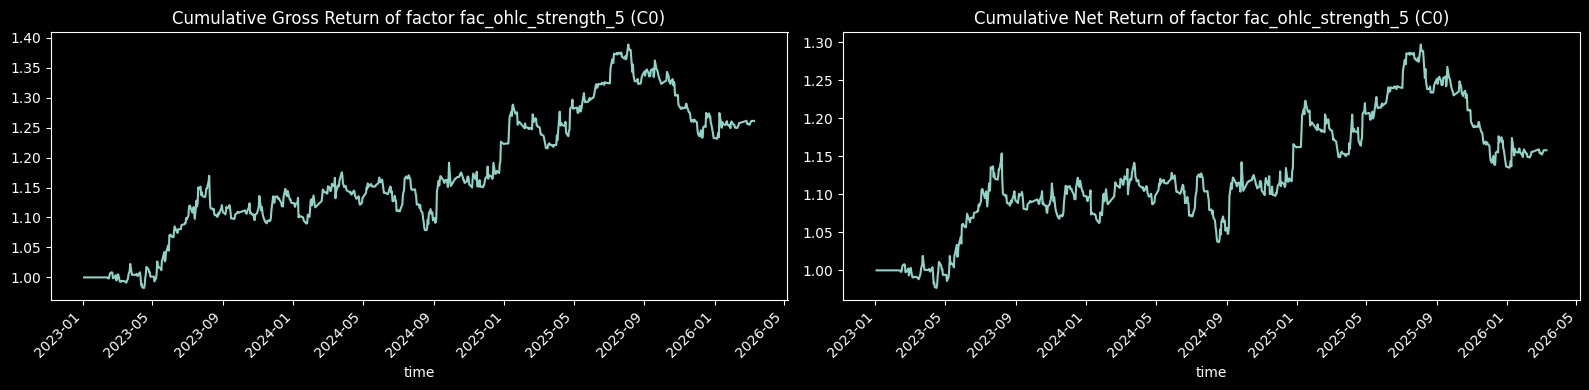

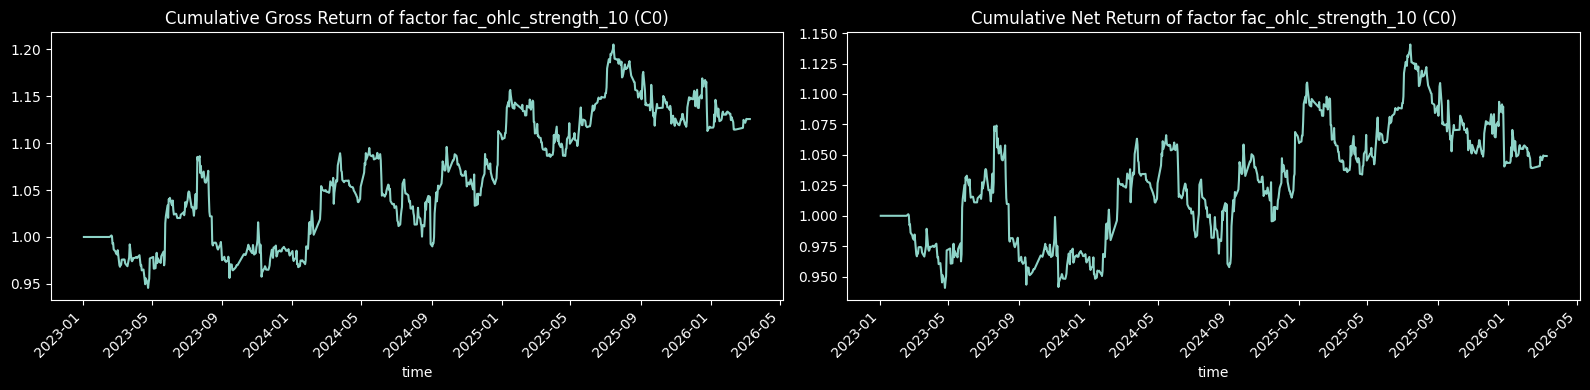

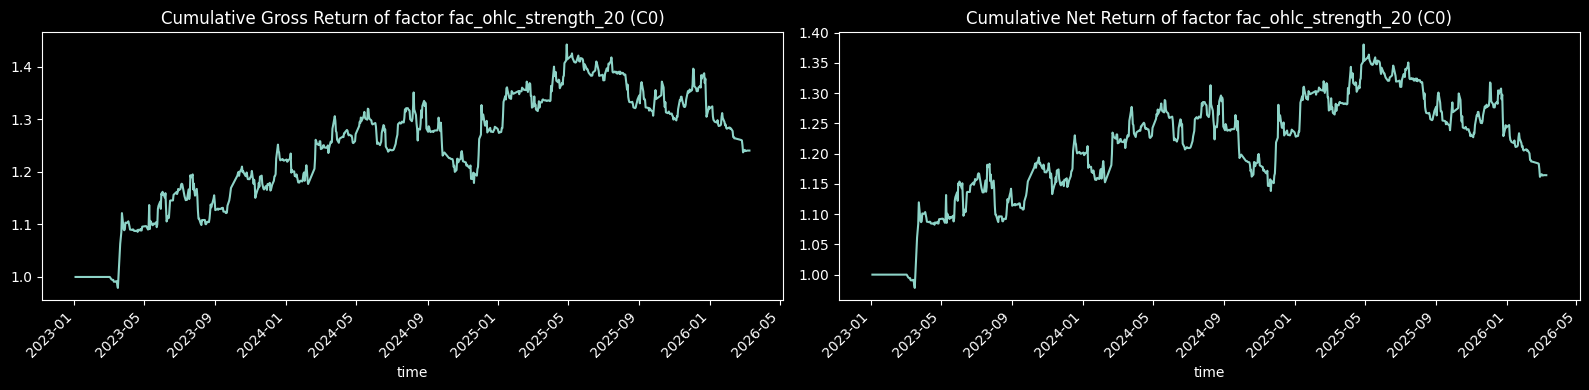

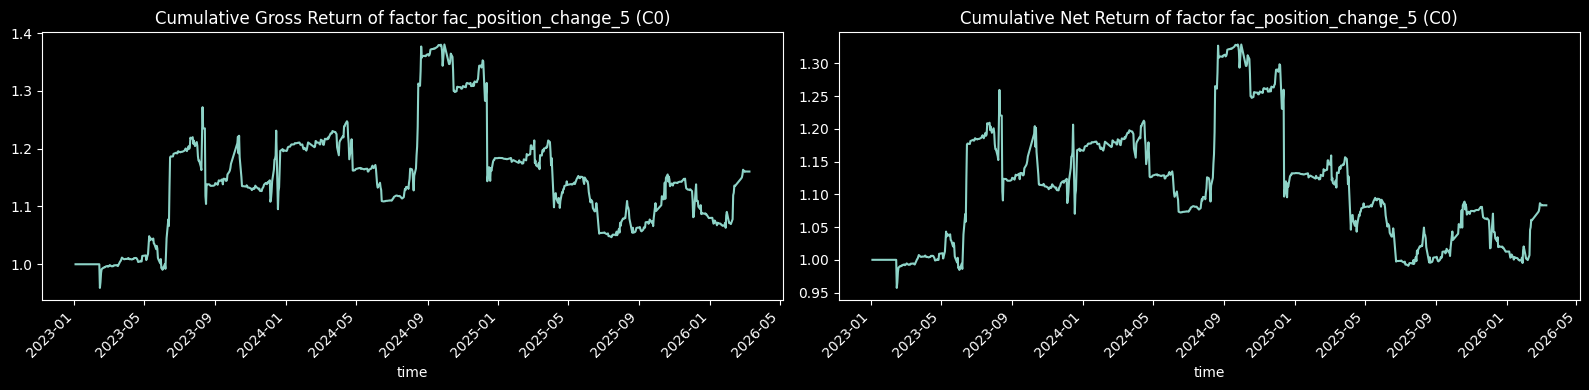

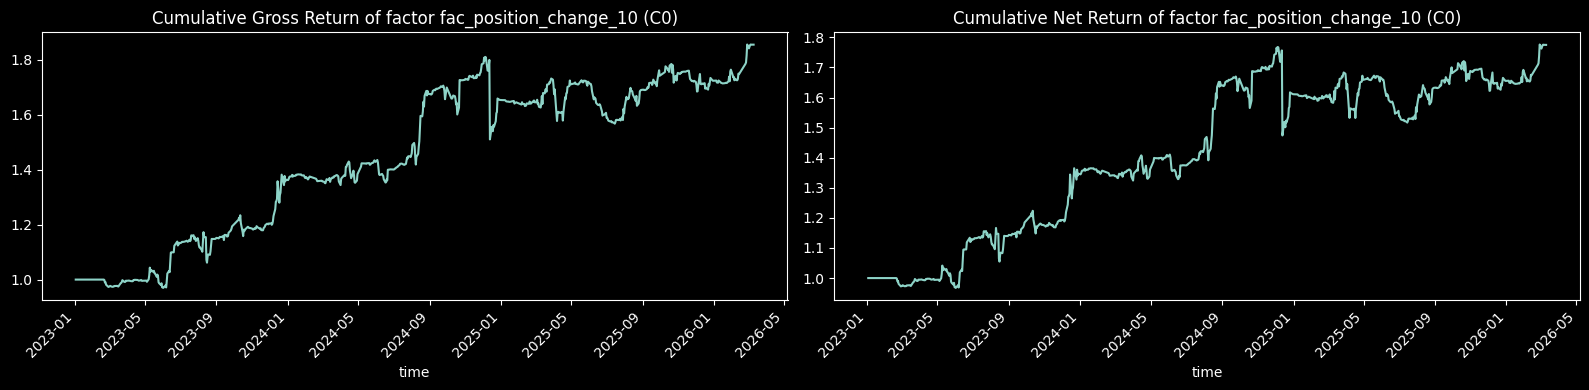

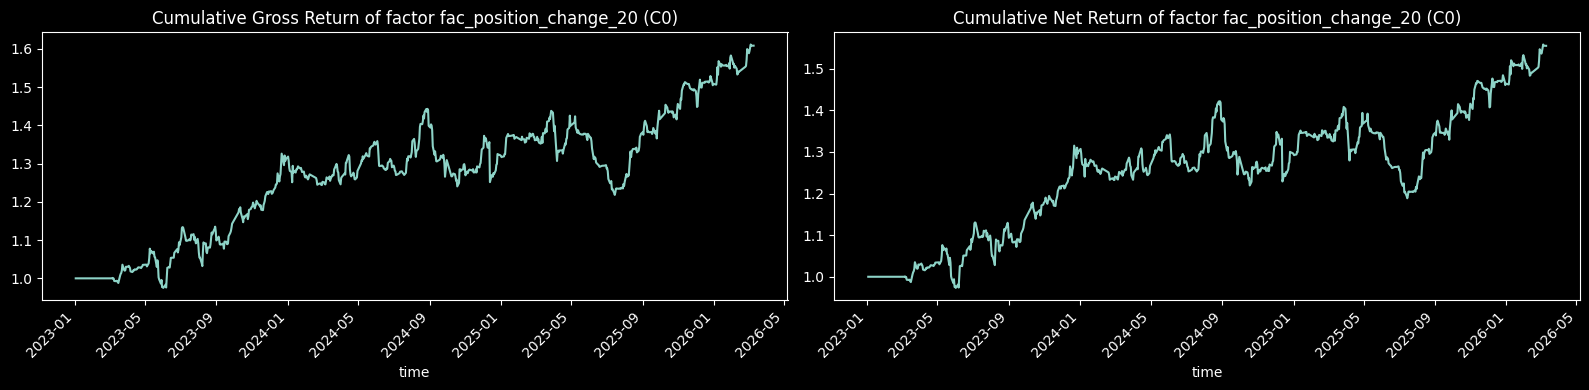

In [6]:
result['bt'].plot_nav()

In [1]:
import os
os.getenv('DEEPSEEK_API_KEY')

In [3]:
from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("/Users/wenglongao/work_repo/lionet/.env"), override=True)

False